In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df_cpi_usa = pd.read_csv("Consumer-Price-Index.csv")

In [59]:
df_cpi_usa.head()

,DATE,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [60]:
df_cpi_usa.info()

<class 'pandas.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DATE      921 non-null    str    
 1   CPIAUCSL  921 non-null    float64
dtypes: float64(1), str(1)
memory usage: 14.5 KB


In [61]:
df_cpi_usa.isnull().sum()

DATE        0
CPIAUCSL    0
dtype: int64

In [62]:
df_cpi_usa['DATE'] = pd.to_datetime(df_cpi_usa['DATE'])
df_cpi_usa= df_cpi_usa.sort_values(by='DATE')
df_cpi_usa= df_cpi_usa.reset_index(drop=True)

In [63]:
df_cpi_usa.describe()

,DATE,CPIAUCSL
count,921,921.000000
mean,1985-05-01 16:09:22.866449,118.407980
min,1947-01-01 00:00:00,21.480000
25%,1966-03-01 00:00:00,32.180000
50%,1985-05-01 00:00:00,107.200000
75%,2004-07-01 00:00:00,189.100000
max,2023-09-01 00:00:00,307.481000
std,NaN,84.285743


In [64]:
df_cpi_usa.duplicated().sum()

np.int64(0)

In [65]:
for col in df_cpi_usa.select_dtypes(include='number').columns:
    Q1 = df_cpi_usa[col].quantile(0.25)
    Q3 = df_cpi_usa[col].quantile(0.75)
    IQR = Q3 - Q1

    df_cpi_usa[col] = df_cpi_usa[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [66]:
cpi_cols = df_cpi_usa.select_dtypes(include='number').columns
df_cpi_usa['CPI_Overall'] = df_cpi_usa[cpi_cols].mean(axis=1)

In [67]:
df_cpi_usa['Inflation'] = df_cpi_usa['CPI_Overall'].pct_change() * 100

In [68]:
df_cpi_usa = df_cpi_usa[['DATE', 'CPI_Overall', 'Inflation']]

In [69]:
df_cpi_usa.to_pickle("df_cpi_usa.pkl")

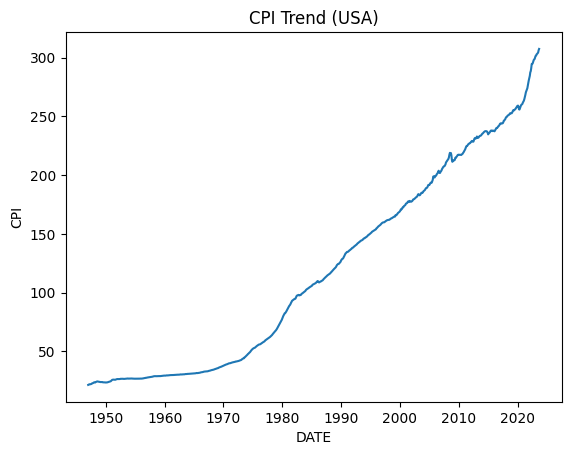

In [70]:
# Inflation Trend Analysis
plt.plot(df_cpi_usa['DATE'], df_cpi_usa['CPI_Overall'])
plt.title("CPI Trend (USA)")
plt.xlabel("DATE")
plt.ylabel("CPI")
plt.show()

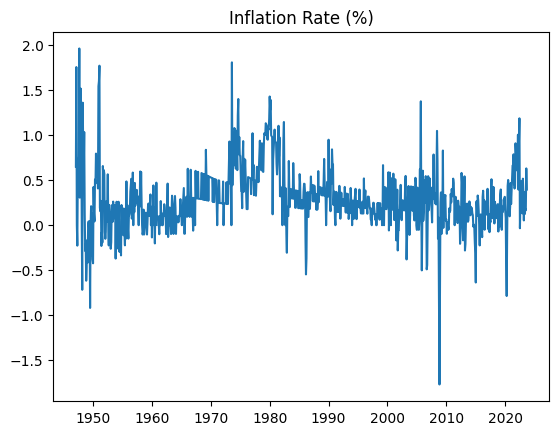

In [71]:
# Inflation Rate Analysis
df_cpi_usa['Inflation'] = df_cpi_usa['CPI_Overall'].pct_change() * 100

plt.plot(df_cpi_usa['DATE'], df_cpi_usa['Inflation'])
plt.title("Inflation Rate (%)")
plt.show()

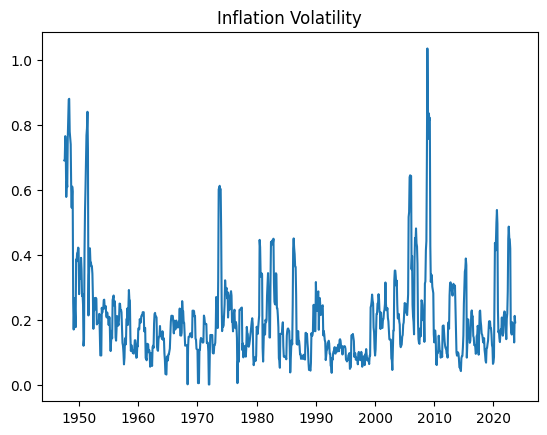

In [73]:
# Volatility of Inflation
df_cpi_usa['Inflation_Volatility'] = df_cpi_usa['Inflation'].rolling(6).std()

plt.plot(df_cpi_usa['DATE'], df_cpi_usa['Inflation_Volatility'])
plt.title("Inflation Volatility")
plt.show()

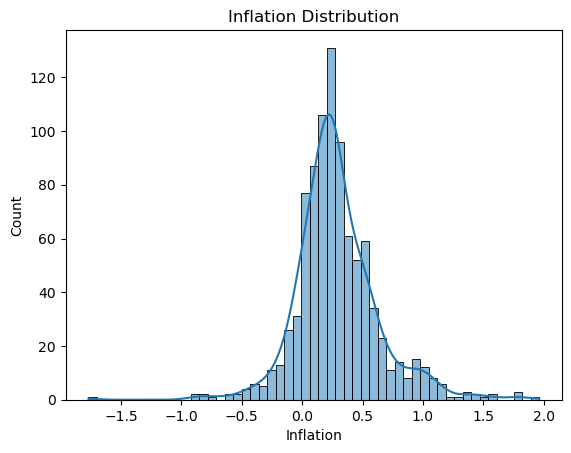

In [ ]:
# Distribution Analysis
sns.histplot(df_cpi_usa['Inflation'], kde=True)
plt.title("Inflation Distribution")
plt.show()

In [ ]:
# Outlier Detection Inflation
Q1 = df_cpi_usa['Inflation'].quantile(0.25)
Q3 = df_cpi_usa['Inflation'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_cpi_usa[(df_cpi_usa['Inflation'] < Q1 - 1.5*IQR) | (df_cpi_usa['Inflation'] > Q3 + 1.5*IQR)]
print(outliers)

          DATE  CPI_Overall  Inflation  Inflation_Volatility
2   1947-03-01       22.000   1.757632                   NaN
8   1947-09-01       22.840   1.964286              0.766047
11  1947-12-01       23.410   1.517780              0.625168
12  1948-01-01       23.680   1.153353              0.609134
14  1948-03-01       23.500  -0.718209              0.812336
15  1948-04-01       23.820   1.361702              0.879091
18  1948-07-01       24.400   1.035197              0.761900
22  1948-11-01       24.160  -0.617030              0.610744
23  1948-12-01       24.050  -0.455298              0.595237
25  1949-02-01       23.910  -0.416493              0.170390
30  1949-07-01       23.700  -0.919732              0.386104
36  1950-01-01       23.510  -0.423549              0.279400
47  1950-12-01       24.980   1.544715              0.408035
48  1951-01-01       25.380   1.601281              0.536714
49  1951-02-01       25.830   1.773050              0.608004
319 1973-08-01       45.